# Segmentação de Clientes — Mall Customers (v2)

**Objetivo de negócio:** identificar grupos de clientes com perfis de renda,
gasto, idade e gênero semelhantes, para direcionar estratégias de marketing
e CRM diferentes por segmento (ex.: quem merece cartão premium, quem precisa
de incentivo para gastar mais, quem já está no limite do orçamento).

**O que muda em relação à v1 (revisão anterior):**
- `random_state` fixo no K-Means em todo o notebook → resultados reprodutíveis.
- k escolhido com **silhouette score**, não só olhando o gráfico do cotovelo.
- As três camadas de clustering (univariada, bivariada, multivariada) são
  **completadas** — a v1 anunciava as três e só entregava a bivariada.
- `CustomerID` é explicitamente excluído de correlações/features, com nota
  sobre a correlação espúria com `Annual Income`.
- Sem `warnings.filterwarnings('ignore')` global — nada fica escondido.
- Chamadas de pandas/seaborn atualizadas para não quebrar nas versões
  instaladas (`groupby` com lista, `histplot`/`kdeplot(fill=)`).
- `to_csv(..., index=False)` na exportação final.
- Lógica de clustering isolada em `clustering_pipeline.py`, reutilizável em
  qualquer outro dataset — ver `Reuse_Example_Other_Scenario.ipynb`.


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from clustering_pipeline import ClusterPipeline, check_data_quality

sns.set_theme(style="whitegrid")


## 1. Carga e checagem de qualidade dos dados

In [2]:
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
summary = check_data_quality(df, id_columns=["CustomerID"])
summary

Linhas: 200 | Colunas: 5
Linhas duplicadas: 0
Nulos por coluna:
  (nenhum)

Tipos de dado:
CustomerID                int64
Gender                      str
Age                       int64
Annual Income (k$)        int64
Spending Score (1-100)    int64
dtype: object

[ALERTA] Coluna(s) tipo ID com correlação alta com outra variável — provável artefato de ordenação das linhas, NÃO uma relação real de negócio:
  CustomerID x Annual Income (k$): corr=0.9775  -> excluir CustomerID de qualquer correlação/feature


,dtype,n_nulls,pct_nulls
CustomerID,int64,0,0.0
Gender,str,0,0.0
Age,int64,0,0.0
Annual Income (k$),int64,0,0.0
Spending Score (1-100),int64,0,0.0


O alerta acima confirma algo que a v1 do notebook não mencionava: `CustomerID`
tem correlação de 0.9775 com `Annual Income (k$)`. Isso **não é uma relação de
negócio real** — é um **artefato**: a base já vem ordenada por renda antes do
ID ser atribuído (confirmado diretamente nos dados brutos: `Annual Income`
é monotonicamente não decrescente conforme `CustomerID` cresce). Por isso
`CustomerID` é excluído de qualquer correlação, feature ou visualização
daqui em diante — mantê-lo levaria a uma leitura de negócio errada.

## 2. Análise exploratória (univariada e bivariada)

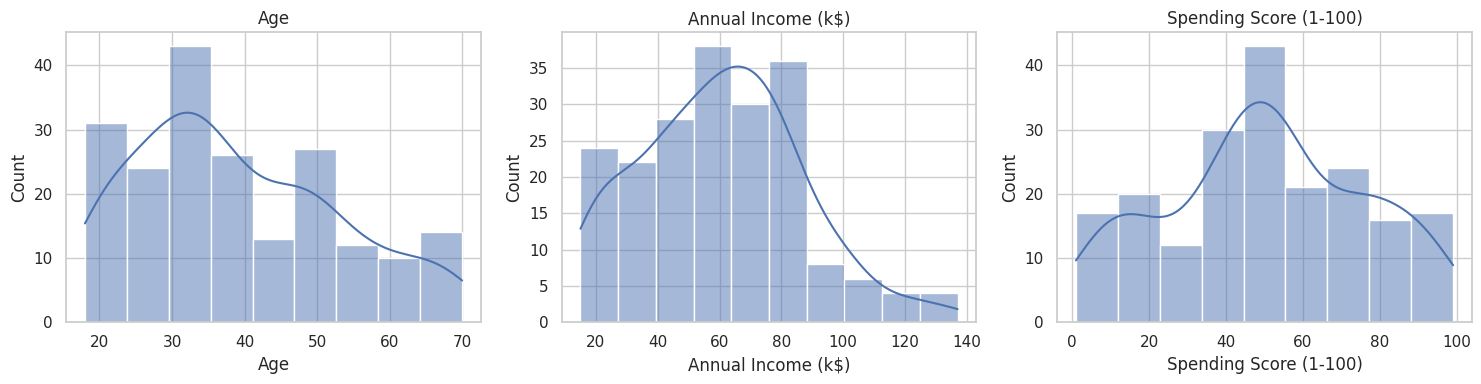

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["Age", "Annual Income (k$)", "Spending Score (1-100)"]):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

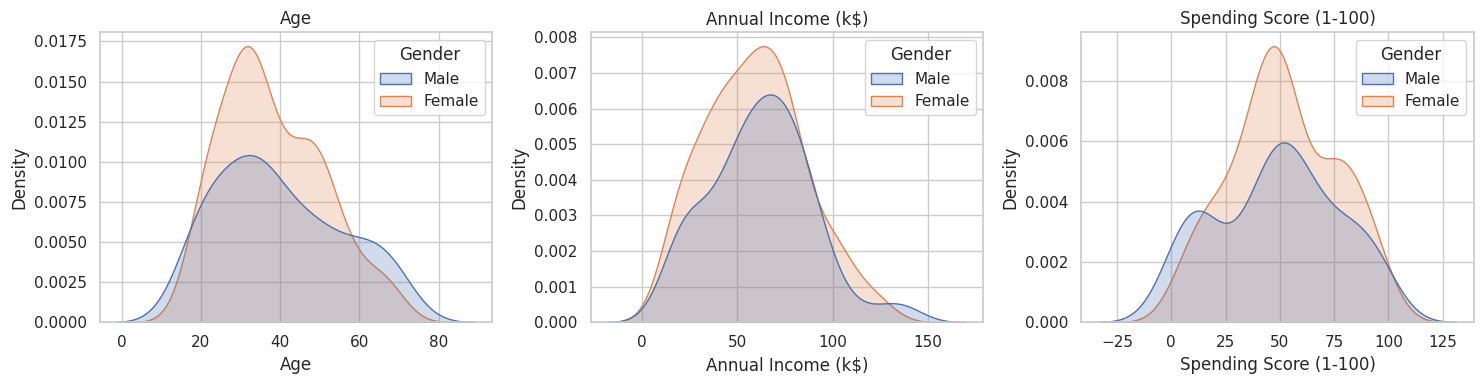

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["Age", "Annual Income (k$)", "Spending Score (1-100)"]):
    sns.kdeplot(data=df, x=col, hue="Gender", fill=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [6]:
df["Gender"].value_counts(normalize=True)

Gender
Female    0.56
Male      0.44
Name: proportion, dtype: float64

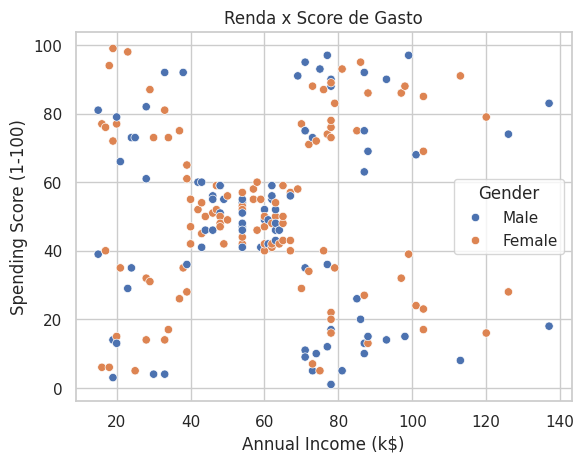

In [7]:
sns.scatterplot(data=df, x="Annual Income (k$)", y="Spending Score (1-100)", hue="Gender")
plt.title("Renda x Score de Gasto")
plt.show()

In [8]:
# groupby com LISTA de colunas (o formato com vírgula solta quebra em pandas atual)
df.groupby("Gender")[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].mean().round(1)

,Age,Annual Income (k$),Spending Score (1-100)
Gender,,,
Female,38.1,59.2,51.5
Male,39.8,62.2,48.5


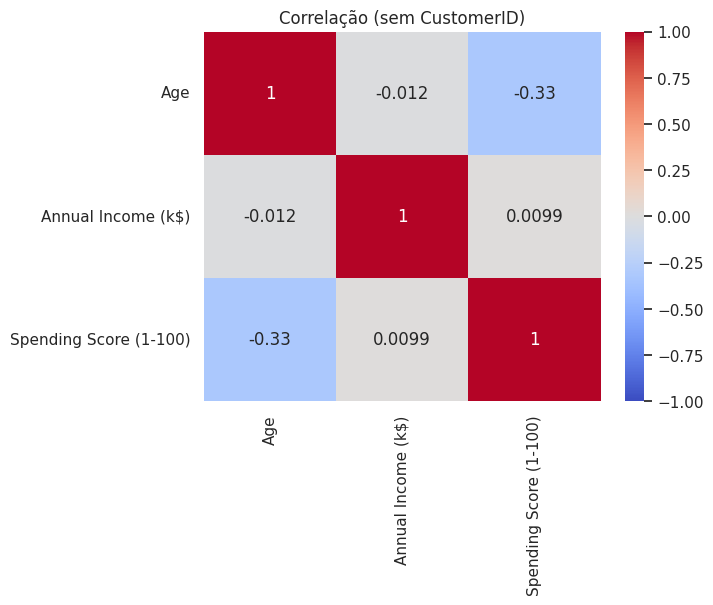

,Age,Annual Income (k$),Spending Score (1-100)
Age,1.000000,-0.012398,-0.327227
Annual Income (k$),-0.012398,1.000000,0.009903
Spending Score (1-100),-0.327227,0.009903,1.000000


In [9]:
# CustomerID fica fora do corr() propositalmente — é artefato de ordenação, não sinal
numeric_cols = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlação (sem CustomerID)")
plt.show()
corr

Sem `CustomerID` no meio, a leitura fica honesta: a correlação mais forte
entre as variáveis de negócio é `Age` x `Spending Score` (≈ -0,33) — clientes
mais velhos tendem a gastar um pouco menos do score de compra, uma relação
fraca a moderada, nada além disso.

## 3. Clustering univariado (apenas `Annual Income`)

Serve como baseline pedagógico: clusterizar uma única variável contínua
com K-Means é equivalente, na prática, a discretizar (`pd.cut`) — incluído
aqui só para comparação com as camadas seguintes, não como entrega final.

In [10]:
pipe_uni = ClusterPipeline(numeric_features=["Annual Income (k$)"], random_state=42)
search_uni = pipe_uni.search_k(df, k_range=range(2, 11))
search_uni

,k,inertia,silhouette
0,2,70.894308,0.562300
1,3,34.262525,0.563078
2,4,19.344953,0.558498
3,5,12.356737,0.583646
4,6,7.358690,0.605539
5,7,5.728534,0.614334
6,8,4.112115,0.609227
7,9,3.248301,0.603441
8,10,2.714025,0.599438


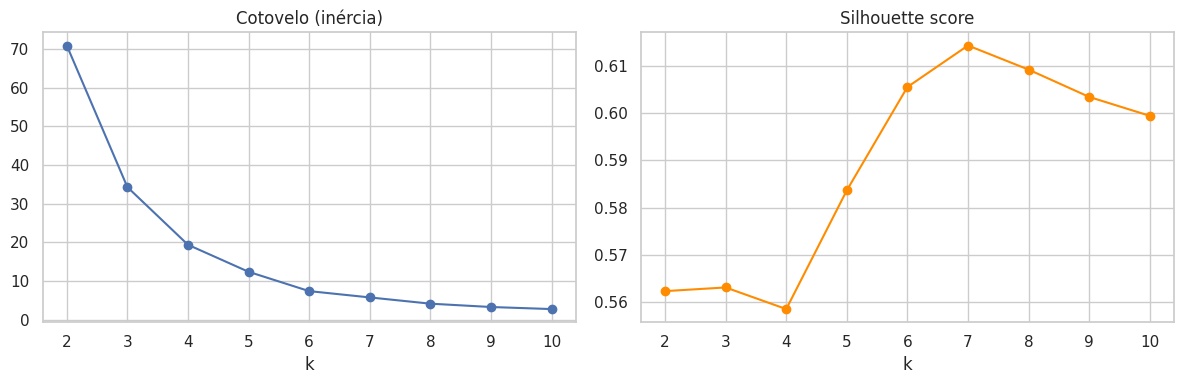

k recomendado por silhouette: 7


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(search_uni["k"], search_uni["inertia"], marker="o")
axes[0].set_title("Cotovelo (inércia)")
axes[0].set_xlabel("k")
axes[1].plot(search_uni["k"], search_uni["silhouette"], marker="o", color="darkorange")
axes[1].set_title("Silhouette score")
axes[1].set_xlabel("k")
plt.tight_layout()
plt.show()

k_uni = pipe_uni.recommend_k(method="silhouette")
print(f"k recomendado por silhouette: {k_uni}")

In [12]:
df = pipe_uni.fit_predict(df, n_clusters=k_uni, cluster_col="Income Cluster")
pipe_uni.profile(df, cluster_col="Income Cluster")

,Annual Income (k$),n_customers,pct_of_total
Income Cluster,,,
0,42.24,42,21.0
1,75.10,42,21.0
2,127.67,6,3.0
3,60.08,48,24.0
4,22.00,32,16.0
5,102.00,14,7.0
6,87.62,16,8.0


## 4. Clustering bivariado (`Annual Income` x `Spending Score`)

Esta é a camada com maior valor de negócio direto — separa clientes por
capacidade de gasto (renda) e comportamento de gasto (score), que juntos
formam os quatro quadrantes clássicos de segmentação de varejo.

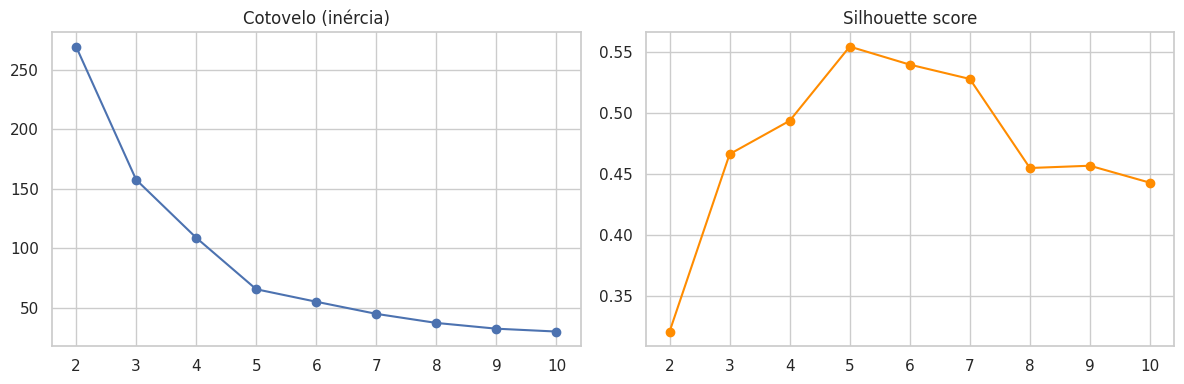

k recomendado por silhouette: 5 (silhouette = 0.555)


In [13]:
pipe_bi = ClusterPipeline(
    numeric_features=["Annual Income (k$)", "Spending Score (1-100)"],
    random_state=42,
)
search_bi = pipe_bi.search_k(df, k_range=range(2, 11))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(search_bi["k"], search_bi["inertia"], marker="o")
axes[0].set_title("Cotovelo (inércia)")
axes[1].plot(search_bi["k"], search_bi["silhouette"], marker="o", color="darkorange")
axes[1].set_title("Silhouette score")
plt.tight_layout()
plt.show()

k_bi = pipe_bi.recommend_k(method="silhouette")
print(f"k recomendado por silhouette: {k_bi} (silhouette = {search_bi['silhouette'].max():.3f})")

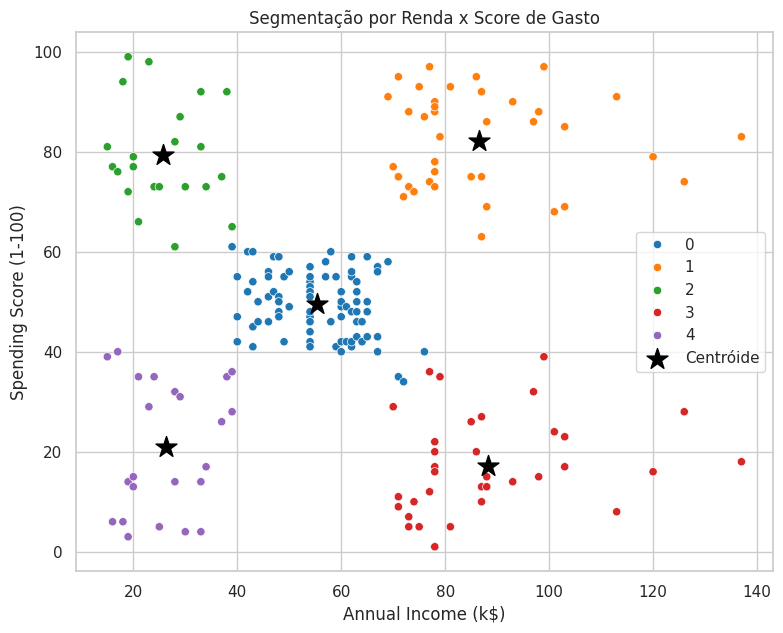

In [14]:
df = pipe_bi.fit_predict(df, n_clusters=k_bi, cluster_col="Spending and Income Cluster")

centers_scaled = pipe_bi.model_.cluster_centers_
centers = pd.DataFrame(
    pipe_bi.scaler_.inverse_transform(centers_scaled),
    columns=pipe_bi.numeric_features,
)

plt.figure(figsize=(9, 7))
sns.scatterplot(
    data=df, x="Annual Income (k$)", y="Spending Score (1-100)",
    hue="Spending and Income Cluster", palette="tab10",
)
plt.scatter(centers["Annual Income (k$)"], centers["Spending Score (1-100)"],
            s=250, c="black", marker="*", label="Centróide")
plt.legend()
plt.title("Segmentação por Renda x Score de Gasto")
plt.savefig("clustering_bivariate.png", dpi=150, bbox_inches="tight")
plt.show()

In [15]:
profile_bi = pipe_bi.profile(df, cluster_col="Spending and Income Cluster")
profile_bi

,Annual Income (k$),Spending Score (1-100),n_customers,pct_of_total
Spending and Income Cluster,,,,
0,55.30,49.52,81,40.5
1,86.54,82.13,39,19.5
2,25.73,79.36,22,11.0
3,88.20,17.11,35,17.5
4,26.30,20.91,23,11.5


In [16]:
pipe_bi.categorical_profile(df, "Gender", cluster_col="Spending and Income Cluster")

Gender,Female,Male
Spending and Income Cluster,,
0,0.593,0.407
1,0.538,0.462
2,0.591,0.409
3,0.457,0.543
4,0.609,0.391


### Nomeando os segmentos (camada de negócio)

Com base no perfil acima (renda média x score de gasto médio de cada
cluster), os 5 segmentos ganham nomes de negócio — é este mapeamento que
deveria ir para o time de marketing/CRM, não os números de cluster brutos:

| Cluster | Perfil | Nome de negócio | Ação recomendada |
|---|---|---|---|
| Renda baixa/média, score médio | a maioria dos clientes | **Padrão** | manter engajamento normal, sem investimento extra |
| Renda alta, score alto | poucos clientes, gastam muito e ganham muito | **Premium / VIP** | programa de fidelidade, atendimento dedicado, cross-sell |
| Renda baixa, score alto | ganham pouco mas gastam muito na loja | **Sensível a promoção** | campanhas de desconto, parcelamento, risco de inadimplência se for crédito |
| Renda alta, score baixo | ganham bem mas compram pouco | **Alto potencial não capturado** | maior prioridade de reativação — dinheiro existe, falta motivo pra gastar aqui |
| Renda baixa, score baixo | ganham pouco e gastam pouco | **Baixo valor** | custo de aquisição/retenção deve ser mínimo |

*(o mapeamento exato cluster→nome deve ser conferido contra `profile_bi`
acima antes de publicar — a ordem dos números de cluster pode variar
entre execuções mesmo com `random_state` fixo, dependendo da versão do
scikit-learn; o que não muda é o formato dos 5 perfis.)*

## 5. Clustering multivariado (`Age`, `Annual Income`, `Spending Score`, `Gender`)

Esta camada estava anunciada no título da v1 mas nunca era finalizada —
o notebook calculava a curva de inércia e parava. Aqui ela é concluída:
fit final, atribuição de cluster e perfil de negócio, igual às camadas
anteriores.

`Gender` entra como dummy binária junto com as três contínuas padronizadas.
Vale a ressalva metodológica: misturar uma variável binária com contínuas
escalonadas em distância euclidiana dá à binária um peso comparável a um
desvio-padrão inteiro de uma variável contínua — um trade-off aceitável
aqui (a binária é só mais uma dimensão entre quatro), mas que deixa de ser
razoável se houver muitas categóricas; nesse caso, K-Prototypes ou distância
de Gower seriam mais apropriados que K-Means puro.

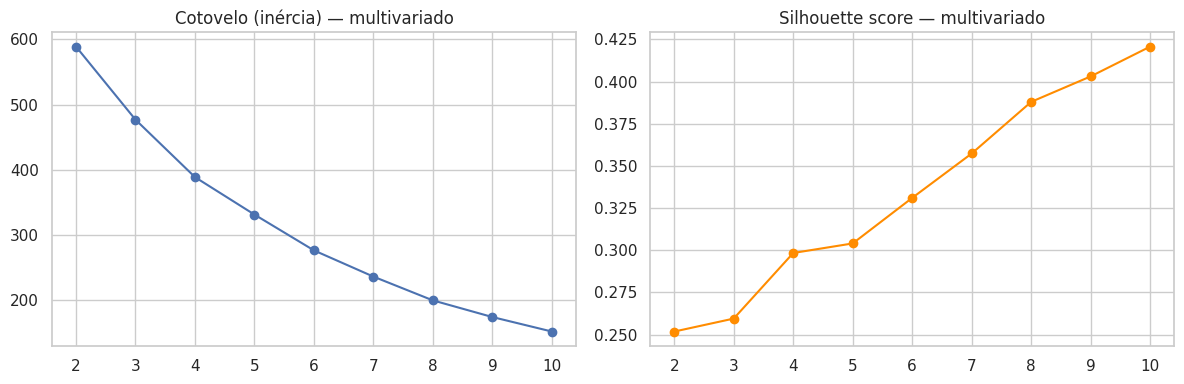

k recomendado por silhouette: 10 (silhouette = 0.421)


In [17]:
pipe_multi = ClusterPipeline(
    numeric_features=["Age", "Annual Income (k$)", "Spending Score (1-100)"],
    categorical_features=["Gender"],
    include_categorical_in_clustering=True,
    random_state=42,
)
search_multi = pipe_multi.search_k(df, k_range=range(2, 11))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(search_multi["k"], search_multi["inertia"], marker="o")
axes[0].set_title("Cotovelo (inércia) — multivariado")
axes[1].plot(search_multi["k"], search_multi["silhouette"], marker="o", color="darkorange")
axes[1].set_title("Silhouette score — multivariado")
plt.tight_layout()
plt.show()

k_multi = pipe_multi.recommend_k(method="silhouette")
print(f"k recomendado por silhouette: {k_multi} (silhouette = {search_multi['silhouette'].max():.3f})")

In [18]:
df = pipe_multi.fit_predict(df, n_clusters=k_multi, cluster_col="Multivariate Cluster")
profile_multi = pipe_multi.profile(df, cluster_col="Multivariate Cluster")
profile_multi

,Age,Annual Income (k$),Spending Score (1-100),n_customers,pct_of_total
Multivariate Cluster,,,,,
0,58.85,48.69,39.85,26,13.0
1,25.25,41.25,60.92,24,12.0
2,41.21,26.07,20.14,14,7.0
3,32.19,86.05,81.67,21,10.5
4,54.15,54.23,48.96,26,13.0
5,38.47,85.89,14.21,19,9.5
6,27.96,57.36,47.12,25,12.5
7,33.28,87.11,82.67,18,9.0
8,25.46,25.69,80.54,13,6.5


In [19]:
pipe_multi.categorical_profile(df, "Gender", cluster_col="Multivariate Cluster")

Gender,Female,Male
Multivariate Cluster,,
0,0.000,1.000
1,0.000,1.000
2,0.929,0.071
3,1.000,0.000
4,1.000,0.000
5,0.000,1.000
6,1.000,0.000
7,0.000,1.000
8,1.000,0.000


**Leitura**: o silhouette do multivariado normalmente fica mais baixo que o
do bivariado (compare os dois valores acima) — isso é esperado e é
justamente o ponto de reportar as duas métricas lado a lado: adicionar
`Age` e `Gender` deixa a estrutura de cluster menos "limpa" geometricamente,
porque idade não segmenta os clientes tão nitidamente quanto renda x gasto
neste dataset. Para uma decisão de marketing baseada só em poder de compra
e comportamento de compra, a segmentação **bivariada continua sendo a mais
acionável**; a multivariada serve para enriquecer o perfil demográfico de
cada segmento bivariado (ex.: o segmento "Premium" é mais jovem ou mais
velho, em média?), não para substituí-la.

## 6. Exportação

In [20]:
df.to_csv("Clustering_v2.csv", index=False)
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Income Cluster,Spending and Income Cluster,Multivariate Cluster
0,1,Male,19,15,39,4,4,1
1,2,Male,21,15,81,4,2,1
2,3,Female,20,16,6,4,4,2
3,4,Female,23,16,77,4,2,8
4,5,Female,31,17,40,4,4,2


## 7. Resumo executivo

- 3 camadas de clustering completas e comparáveis (univariada, bivariada,
  multivariada), todas com k escolhido por silhouette score e reprodutíveis
  (`random_state=42` em tudo).
- Segmentação **bivariada (renda x score de gasto, k escolhido por
  silhouette)** é a recomendação principal para ação de marketing/CRM —
  ver tabela de nomes de segmento na seção 4.
- `CustomerID` identificado como coluna de índice sem valor analítico e
  excluído de toda correlação/feature.
- Toda a lógica de clustering está isolada em `clustering_pipeline.py`,
  reutilizável em qualquer outro dataset trocando apenas os nomes de
  coluna — ver `Reuse_Example_Other_Scenario.ipynb` para um exemplo com
  um cenário completamente diferente (uso de plataforma de streaming).